## Cell type annotation

UniST performs cell type annotation by transferring labels from original cells to newly generated synthetic coordinates via KNN search in a hybrid space that combines transcriptomic embeddings (from GAE-INR) and spatial coordinates.

In [1]:
!git clone https://github.com/lanshui98/UniST.git
%cd UniST

Cloning into 'UniST'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (360/360), done.
remote: Compressing objects: 100% (322/322), done.
remote: Total 360 (delta 140), reused 179 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (360/360), 7.42 MiB | 12.60 MiB/s, done.
Resolving deltas: 100% (140/140), done.
/content/UniST


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2

In [3]:
! pip install scanpy

In [4]:
import random
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scanpy as sc

#### We illustrate the cell annotation using Spateo 2D slice.

In [ ]:
%cd external/SUICA_pro

In [11]:
adata_path = 'data/slice_440.h5ad'
slice = sc.read(adata_path)

In [12]:
slice

View of AnnData object with n_obs × n_vars = 8382 × 17649
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region'
    obsm: '3d_align_spatial', 'X_pca', 'bbox', 'global_align_spatial', 'spatial'

In [13]:
### Mapping cell types to 9 major cell types according to Spateo paper

celltype_to_9major = {
    "Spinal cord motor neurons": "CNS neurons",
    "Spinal cord dorsal progenitors": "CNS neurons",
    "Spinal cord ventral progenitors": "CNS neurons",
    "Cranial motor neurons": "CNS neurons",
    "Glutamatergic neurons": "CNS neurons",
    "Neural progenitor cells": "CNS neurons",
    "Neuroectoderm-derived": "CNS neurons",
    "Neural crest (PNS neurons)": "PNS neurons",
    "Neural crest (PNS glia)": "PNS glia",
    "Epithelial precursors": "Epithelium",
    "Placode and neural crest-derived": "Epithelium",
    "Ectoderm-derived": "Epithelium",
    "Amniotic ectoderm": "Epithelium",
    "Anterior intermediate mesoderm": "Epithelium",
    "Intermediate mesoderm": "Epithelium",
    "Olfactory epithelial cells": "Epithelium",
    "Otic epithelial cells": "Epithelium",
    "Gut": "Epithelium",
    "Endothelium": "Endothelium",
    "Vessel endothelial cells": "Endothelium",
    "Arterial endothelial cells": "Endothelium",
    "Hematoendothelial progenitors": "Endothelium",
    "Endocardial cells": "Endothelium",
    "Liver sinusoidal endothelial cell precursors": "Endothelium",
    "Primitive erythroid cells": "Blood lineages",
    "Second heart field-derived cardiomyocytes": "Cardiomyocytes",
    "LV/atrioventricular canal/common atrium cardiomyocytes": "Cardiomyocytes",
    "Cranial mesoderm": "Mesoderm",
    "Head and facial mesenchyme": "Mesoderm",
    "Cardiopharyngeal mesoderm": "Mesoderm",
    "Dermomyotome": "Mesoderm",
    "Lateral plate mesoderm": "Mesoderm",
    "Sclerotome": "Mesoderm",
    "Proepicardium": "Mesoderm",
    "Mesodermal progenitors": "Mesoderm",
    "Hepatic mesenchyme": "Mesoderm",
    "Gut mesenchyme": "Mesoderm",
    "Renal mesenchyme": "Mesoderm",
    "Limb progenitors and lateral plate mesoderm": "Mesoderm",
    "Spinal cord neuroectoderm": "Neuroectoderm",
    "Hindbrain neuroectoderm": "Neuroectoderm",
    "Midbrain-hindbrain boundary": "Neuroectoderm",
    "Midbrain neuroectoderm": "Neuroectoderm",
    "Telencephalon neuroectoderm": "Neuroectoderm",
    "Diencephalon neuroectoderm": "Neuroectoderm",
    "Hypothalamus (Sim1+) neuroectoderm": "Neuroectoderm",
    "Hypothalamus neuroectoderm": "Neuroectoderm",
    "Dorsal telencephalon neuroectoderm": "Neuroectoderm",
    "Anterior floor plate": "Neuroectoderm",
    "Anterior roof plate": "Neuroectoderm",
    "Posterior roof plate": "Neuroectoderm",
    "Eye field": "Neuroectoderm",
    "NMPs and spinal cord progenitors": "Neuroectoderm"
}

slice.obs['mapped_celltype_nine'] = slice.obs['mapped_celltype'].map(celltype_to_9major)

/tmp/ipython-input-1172833971.py:59: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  slice.obs['mapped_celltype_nine'] = slice.obs['mapped_celltype'].map(celltype_to_9major)


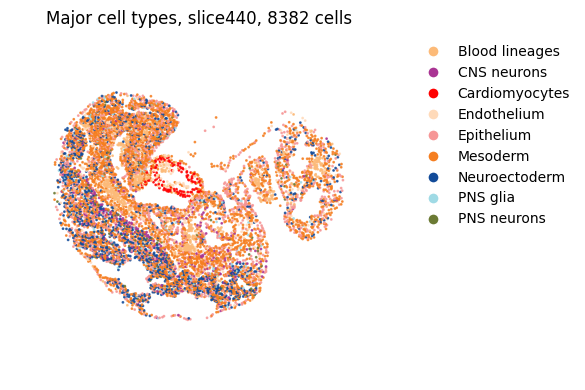

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

coords = slice.obsm['global_align_spatial']
labels = slice.obs['mapped_celltype_nine']

major_class_colors = {
    "CNS neurons": "#A93493",
    "PNS neurons": "#6B7A34",
    "PNS glia": "#9FDAE5",
    "Epithelium": "#F69696",
    "Endothelium": "#FFDAB9",
    "Blood lineages": "#FCBA78",
    "Mesoderm": "#F57E20",
    "Neuroectoderm": "#124B99",
    "Cardiomyocytes": "#FF0000",
}

unique_labels = sorted(labels.dropna().unique())

label_to_color = {label: major_class_colors.get(label, "#CCCCCC") for label in unique_labels}
colors = [label_to_color.get(l, "#CCCCCC") for l in labels]

plt.figure(figsize=(6, 4))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, s=1, alpha=0.8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Major cell types, slice440, {slice.shape[0]} cells')
plt.axis('equal')
plt.box(False)
plt.axis('off')

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',                      # 线条颜色设为白色（不显示）
        markerfacecolor=label_to_color[label],
        markersize=8,                   # 控制点大小
        label=label
    )
    for label in unique_labels
]

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
#plt.savefig('/content/spatial_plot_440.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

#### Read in embeded features from original slice and generate slice.

In [17]:
emb = sc.read('logs/GAE-2D/2d/lightning_logs/version_0/embedded-all.h5ad')

In [18]:
emb

AnnData object with n_obs × n_vars = 8382 × 17649
    obsm: 'embeddings', 'spatial'